## Initialization

In [1]:
import os
import numpy as np
from scipy.stats import pearsonr
import NPI
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.io as sio
import logging
import torch
import pandas as pd

### **NPI usage demo**
hyperparams = {
    "ROI_num": 400,
    "using_steps": 5,
    "hidden_dim_factor": 2,      # 隐藏层是 ROI 的几倍
    "latent_dim_factor": 0.8,    # 压缩层是 ROI 的几倍
    "batch_size": 50,
    "train_set_proportion": 0.8,
    "num_epochs": 100
}
total_subs = 177
batch_size              = 50
train_set_proportion    = 0.8
ROI_num                 = 400
using_steps             = 3
num_epochs              = 100

save_dir = r"F:\NPI_results\bs_50"  # 存放模型和日志的目录

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def flat_without_diagonal(matrix):

    "Flatten the matrix without including the diagonal"
    
    n = matrix.shape[0]
    flattened = []
    for i in range(n):
        for j in list(range(i)) + list(range(i + 1, n)):
            flattened.append(matrix[i][j])
    
    return np.array(flattened)

### BOLD DATA IMPORT

In [3]:
# 加载MAT文件

data_root = r"F:\EOS_TD_data"
file_name = 'data_400_208_177.mat'
full_path = os.path.join(data_root, file_name)

mat_data = sio.loadmat(full_path) 
all_subjects_data = mat_data['ROI400']
all_subjects_data = all_subjects_data.transpose(2, 1, 0)

### Configuration logging

In [4]:
# 配置日志记录：同时输出到文件和屏幕
current_dir = os.getcwd() 
log_path = os.path.join(current_dir, "training_log.log")

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler(log_path),
        logging.StreamHandler()
    ]
)

## Training all subs ANN models

In [11]:
# Training 177 subs
target_subjects = range(0, 177)

# --- 在循环开始前，打印本次实验的总配置 ---
logging.info("="*30 + " NEW EXPERIMENT START " + "="*30)
logging.info("Current Hyperparameters Configuration:")
for key, value in hyperparams.items():
    logging.info(f" - {key}: {value}")
logging.info("="*80)


for sub_idx in target_subjects:
    model_path = os.path.join(save_dir, f"ANN_Sub_{sub_idx}.pth")
    
    # 检查是否已经训练过该被试（断点保护）
    if os.path.exists(model_path):
        logging.info(f"Skipping Subject {sub_idx}: Model already exists.")
        continue

    logging.info(f"Starting Subject {sub_idx}...")

    try:
        # 1. 提取当前被试数据并预处理
        # 假设 sub_data 维度是 (208, 400) -> (Time, ROIs)
        sub_data = all_subjects_data[sub_idx] 
        
        inputs, targets = NPI.multi2one(sub_data, steps=using_steps)

        # 2. 初始化模型
        ANN = NPI.ANN_MLP(
            input_dim = using_steps * ROI_num, 
            hidden_dim = 2 * ROI_num, 
            latent_dim = int(0.8 * ROI_num), 
            output_dim = ROI_num
        )

        # 3. 开始训练
        ANN, training_loss, testing_loss = NPI.train_NN(
            ANN, inputs, targets, 
            batch_size = batch_size, 
            train_set_proportion = 0.8, 
            num_epochs = num_epochs, 
            lr = 1e-3, 
            l2 = 5e-5
        )

        # 4. 保存模型和训练曲线
        # 保存整个模型或状态字典
        torch.save({
            'model_state_dict': ANN.state_dict(),
            'training_loss': training_loss,
            'testing_loss': testing_loss
        }, model_path)
        
        logging.info(f"被试 {sub_idx} 训练完成并保存。Final Test Loss: {testing_loss[-1]:.6f}")

        # 5. 显存清理（针对 P620 的关键操作）
        del ANN, inputs, targets
        torch.cuda.empty_cache()

    except Exception as e:
        logging.error(f"被试 {sub_idx} 训练出错: {str(e)}")
        # 出错后继续下一个被试，而不是让整个程序崩溃
        continue

logging.info("所有预定训练任务已结束。")

2026-02-01 15:44:56,898 [INFO] ============================== NEW EXPERIMENT START ==============================
2026-02-01 15:44:56,898 [INFO] Current Hyperparameters Configuration:
2026-02-01 15:44:56,899 [INFO]  - ROI_num: 400
2026-02-01 15:44:56,900 [INFO]  - using_steps: 5
2026-02-01 15:44:56,901 [INFO]  - hidden_dim_factor: 2
2026-02-01 15:44:56,902 [INFO]  - latent_dim_factor: 0.8
2026-02-01 15:44:56,902 [INFO]  - batch_size: 50
2026-02-01 15:44:56,903 [INFO]  - train_set_proportion: 0.8
2026-02-01 15:44:56,904 [INFO]  - num_epochs: 100
2026-02-01 15:44:56,904 [INFO] ================================================================================
2026-02-01 15:44:56,905 [INFO] Starting Subject 0...
2026-02-01 15:45:00,312 [INFO] 被试 0 训练完成并保存。Final Test Loss: 0.228662
2026-02-01 15:45:00,314 [INFO] Starting Subject 1...
2026-02-01 15:45:01,632 [INFO] 被试 1 训练完成并保存。Final Test Loss: 2.665577
2026-02-01 15:45:01,634 [INFO] Starting Subject 2...
2026-02-01 15:45:02,947 [INFO] 被试 2 训练

## 重写 FC / EC

In [8]:
''' 重写 FC / EC 逻辑'''
from tqdm import tqdm
all_stats = []
EC_overwrite = True # 是否覆盖已存在的EC
stats_recalc = False
logging.info("="*30 + " FC and EC START " + "="*30)
logging.info("="*80)

total_subs = 177
for sub_idx in tqdm(range(total_subs), desc="Processing subjects"):
    pth_path = os.path.join(save_dir, f"ANN_Sub_{sub_idx}.pth")
    ec_mat_path = os.path.join(save_dir, f"EC_Sub_{sub_idx}.mat")

    if not os.path.exists(pth_path):
        logging.info(f"Missing model for Sub {sub_idx}, skipping.")
        logging.info("Recheck the pth data!")
        break
    ANN = NPI.ANN_MLP(
        input_dim=using_steps*ROI_num, 
        hidden_dim=2*ROI_num, 
        latent_dim=int(0.8*ROI_num), 
        output_dim=ROI_num
    )

    checkpoint = torch.load(pth_path, map_location=device)
    ANN.load_state_dict(checkpoint['model_state_dict'])
    ANN.eval() # 切换到预测模式
    
    # 计算FC 及 r p
    with torch.no_grad():
        model_FC = NPI.model_FC(ANN, node_num=ROI_num, steps=using_steps)
        emp_bold = all_subjects_data[sub_idx]
        empirical_FC = NPI.corrcoef(emp_bold)

        vec_model = flat_without_diagonal(model_FC)
        vec_emp = flat_without_diagonal(empirical_FC)

        try:
            r_value, p_value = pearsonr(vec_model, vec_emp)
            logging.info(f" Sub {sub_idx} FC correlation: r = {r_value}, p = {p_value}")
        except Exception as e:
            logging.error(f"!!! Sub {sub_idx} 发生毁灭性错误: {e}")
            # 给它填入默认的 0 值，保证 CSV 长度一致
            all_stats.append({'Subject_Index': sub_idx, 'FC_r': 0, 'FC_p': 1})
            continue
    
    # 计算 EC 
    if not EC_overwrite and os.path.exists(ec_mat_path):
        logging.info(f"Sub {sub_idx} EC already exists. Skipping calculation.")
    else:
        logging.info(f"Calculating EC for Sub {sub_idx}...")
        inputs, targets = NPI.multi2one(emp_bold, steps=using_steps)
        NPI_EC = NPI.model_EC(ANN, inputs, targets, pert_strength=1.0)
        np.fill_diagonal(NPI_EC, 0)

        ec_payload = {
                    'EC': NPI_EC.astype(np.float32),
                    'r_value': r_value,
                    'p_value': p_value,
                    'subject_id': sub_idx
                }
        
        sio.savemat(ec_mat_path, ec_payload, do_compression=True)
        logging.info(f"Sub {sub_idx} EC saved to {ec_mat_path}")

    
    
    all_stats.append({
        'Subject_Index': sub_idx,
        'FC_r': r_value,
        'FC_p': p_value
    })

    
    for var in ['ANN', 'model_FC', 'empirical_FC', 'NPI_EC']:
        if var in locals():
            exec(f"del {var}")

    torch.cuda.empty_cache()


import datetime
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
df = pd.DataFrame(all_stats)
try:
    csv_path = os.path.join(save_dir, f"NPI_Statistics_Summary_{total_subs}_{current_time}.csv")
    df.to_csv(csv_path, index=False, encoding='utf-8-sig')
except PermissionError:
    backup_path = csv_path.replace(".csv", f"_backup_{len(all_stats)}_{total_subs}_{current_time}.csv")
    df.to_csv(backup_path, index=False, encoding='utf-8-sig')
    logging.error(f"无法写入主CSV（可能被Excel打开了），数据已紧急备份至: {backup_path}")



logging.info(f"\n统计结果已保存至: {csv_path}")

2026-02-02 16:38:33,839 [INFO] ============================== FC and EC START ==============================
2026-02-02 16:38:33,841 [INFO] ================================================================================
Processing subjects:   0%|          | 0/177 [00:00<?, ?it/s]2026-02-02 16:38:34,827 [INFO]  Sub 0 FC correlation: r = 0.7993152532063071, p = 0.0
2026-02-02 16:38:34,828 [INFO] Calculating EC for Sub 0...
2026-02-02 16:38:36,620 [INFO] Sub 0 EC saved to F:\NPI_results\bs_50\EC_Sub_0.mat
Processing subjects:   1%|          | 1/177 [00:02<08:08,  2.78s/it]2026-02-02 16:38:37,370 [INFO]  Sub 1 FC correlation: r = 0.8047410757620738, p = 0.0
2026-02-02 16:38:37,371 [INFO] Calculating EC for Sub 1...
2026-02-02 16:38:39,178 [INFO] Sub 1 EC saved to F:\NPI_results\bs_50\EC_Sub_1.mat
Processing subjects:   1%|          | 2/177 [00:05<07:43,  2.65s/it]2026-02-02 16:38:39,931 [INFO]  Sub 2 FC correlation: r = 0.6093804087651385, p = 0.0
2026-02-02 16:38:39,932 [INFO] Calculatin

## 排查某个被试

### 重新训练 单个 sub ANN

2026-02-01 22:23:09,016 [INFO] Starting Subject 36...


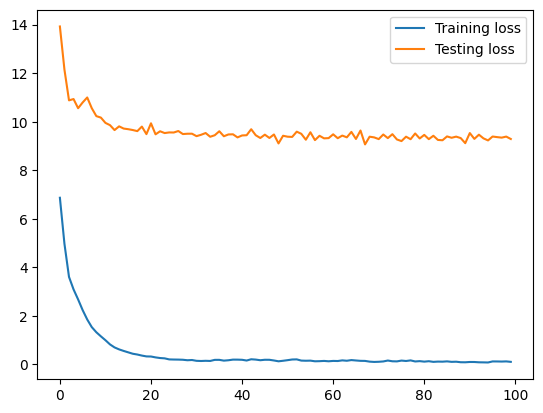

2026-02-01 22:23:10,663 [INFO] 被试 36 训练完成并保存。Final Test Loss: 9.287624
2026-02-01 22:23:10,665 [INFO] 所有预定训练任务已结束。


In [34]:
''' sub 36 retrainning + csv '''
id = 36



for sub_idx in [id]:
    model_path = os.path.join(save_dir, f"ANN_Sub_{sub_idx}.pth")
    
    # 检查是否已经训练过该被试（断点保护）
    # if os.path.exists(model_path):
    #     logging.info(f"Skipping Subject {sub_idx}: Model already exists.")
    #     continue

    logging.info(f"Starting Subject {sub_idx}...")

    try:
        # 1. 提取当前被试数据并预处理
        # 假设 sub_data 维度是 (208, 400) -> (Time, ROIs)
        sub_data = all_subjects_data[sub_idx] 
        
        # 使用 NPI 提供的工具转换数据格式
        inputs, targets = NPI.multi2one(sub_data, steps=using_steps)

        # 2. 初始化模型
        ANN = NPI.ANN_MLP(
            input_dim = using_steps * ROI_num, 
            hidden_dim = 2 * ROI_num, 
            latent_dim = int(0.8 * ROI_num), 
            output_dim = ROI_num
        )

        # 3. 开始训练
        # 注意：NPI.train_NN 内部应该已经处理了 .to(device)
        ANN, training_loss, testing_loss = NPI.train_NN(
            ANN, inputs, targets, 
            batch_size = batch_size, 
            train_set_proportion = 0.8, 
            num_epochs = num_epochs, 
            lr = 1e-3, 
            l2 = 5e-5
        )

        # 4. 保存模型和训练曲线

        plt.plot(training_loss, label = 'Training loss')
        plt.plot(testing_loss, label = 'Testing loss')
        plt.legend(loc = 'upper right')
        plt.show()
        
        # 保存整个模型或状态字典
        torch.save({
            'model_state_dict': ANN.state_dict(),
            'training_loss': training_loss,
            'testing_loss': testing_loss
        }, model_path)
        
        logging.info(f"被试 {sub_idx} 训练完成并保存。Final Test Loss: {testing_loss[-1]:.6f}")

        # 5. 显存清理（针对 P620 的关键操作）
        del ANN, inputs, targets
        torch.cuda.empty_cache()

    except Exception as e:
        logging.error(f"被试 {sub_idx} 训练出错: {str(e)}")
        # 出错后继续下一个被试，而不是让整个程序崩溃
        continue

logging.info("所有预定训练任务已结束。")

### 可视化 FC 排查

2026-02-01 22:36:08,919 [INFO] ============================== 可视化sub <built-in function id> 的 model FC & empirical FC==============================
2026-02-01 22:36:08,920 [INFO] :
2026-02-01 22:36:08,921 [INFO] ================================================================================


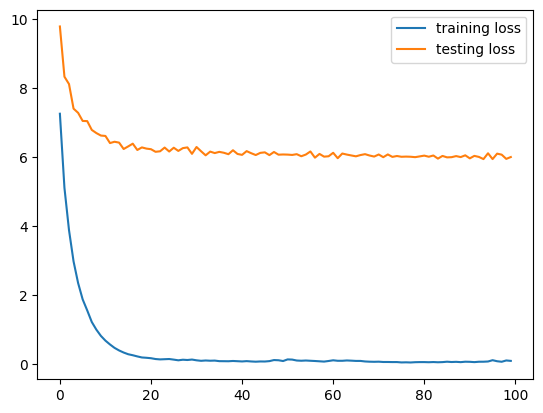

【检查 A】模型权重是否存在 NaN: False
【检查 B】生成的 Model FC 最大值: 1.0
【检查 B】生成的 Model FC 最小值: -0.885992705821991
【检查 B】生成的 Model FC 是否含 NaN: False
r_value is 0.6154894895304522
p_value is 0.0


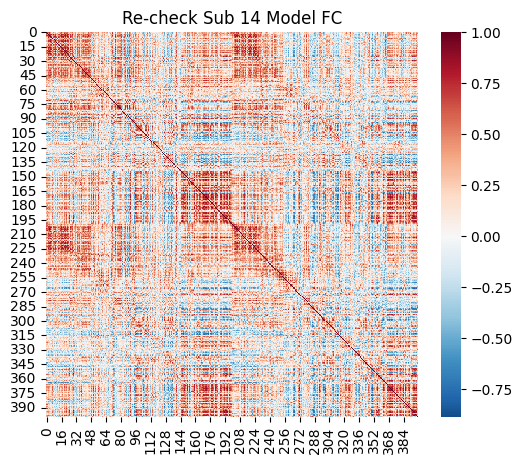

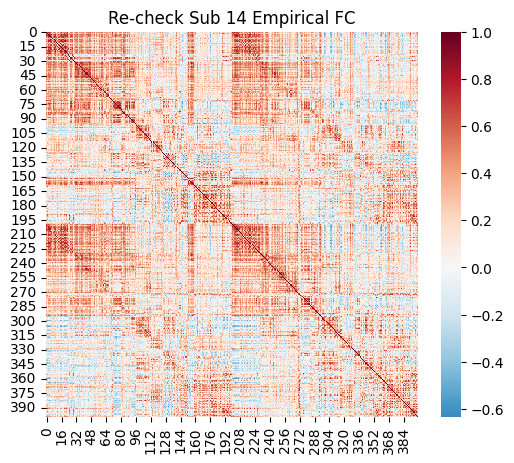

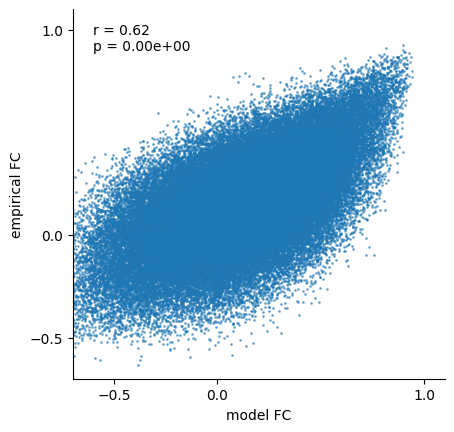

In [6]:
''' vision sub_x FC'''
import torch
import numpy as np

# --- 在循环开始前，打印本次实验的总配置 ---
logging.info("="*30 + f" 可视化sub {id} 的 model FC & empirical FC" + "="*30)
logging.info(":")
logging.info("="*80)

# --- 1. 环境配置 (确保与你主程序一致) ---
sub_idx = 14
pth_path = os.path.join(save_dir, f"ANN_Sub_{sub_idx}.pth")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. 重新初始化并加载模型 ---
test_ANN = NPI.ANN_MLP(
    input_dim=using_steps*ROI_num, 
    hidden_dim=2*ROI_num, 
    latent_dim=int(0.8*ROI_num), 
    output_dim=ROI_num
).to(device)

checkpoint = torch.load(pth_path, map_location=device)
test_ANN.load_state_dict(checkpoint['model_state_dict'])
test_ANN.eval()

train_loss_history = checkpoint.get('training_loss', []) 
test_loss_history = checkpoint.get('testing_loss', [])
plt.plot(train_loss_history, label = 'training loss')

plt.plot(test_loss_history, label = 'testing loss')

plt.legend(loc = 'upper right')

plt.show()

# --- 检查点 A：检查模型权重本身是否有问题 ---
has_nan_weight = any(torch.isnan(p).any() for p in test_ANN.parameters())
print(f"【检查 A】模型权重是否存在 NaN: {has_nan_weight}")

# --- 3. 生成 model_FC ---
with torch.no_grad():
    # 模拟生成过程
    m_fc = NPI.model_FC(test_ANN, node_num=ROI_num, steps=using_steps)

# --- 检查点 B：检查生成的 FC 矩阵 ---
print(f"【检查 B】生成的 Model FC 最大值: {np.nanmax(m_fc)}")
print(f"【检查 B】生成的 Model FC 最小值: {np.nanmin(m_fc)}")
print(f"【检查 B】生成的 Model FC 是否含 NaN: {np.isnan(m_fc).any()}")


# --- 4. 可视化测试 ---
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6, 5))
sns.heatmap(m_fc, cmap='RdBu_r', center=0)
plt.title(f"Re-check Sub {sub_idx} Model FC")

sub_data = all_subjects_data[sub_idx]
e_fc = NPI.corrcoef(sub_data)
plt.figure(figsize=(6, 5))
sns.heatmap(e_fc, cmap='RdBu_r', center=0)
plt.title(f"Re-check Sub {sub_idx} Empirical FC")

inputs, targets = NPI.multi2one(sub_data, steps=using_steps)
test_EC= NPI.model_EC(test_ANN, inputs, targets, pert_strength = 1.0)


r_value, p_value = pearsonr(flat_without_diagonal(m_fc), flat_without_diagonal(e_fc))
print(f'r_value is {r_value}')
print(f'p_value is {p_value}')

# scatter plot
plt.figure(figsize = (4.8, 4.8))
plt.scatter(flat_without_diagonal(m_fc), flat_without_diagonal(e_fc), s=1, alpha=0.3)

plt.xlim(-0.7, 1.1); plt.ylim(-0.7, 1.1)
plt.xticks([-0.5, 0.0, 1.0]); plt.yticks([-0.5, 0.0, 1.0])
plt.xlabel('model FC'); plt.ylabel('empirical FC')


plt.text(-0.6, 0.9, f'r = {r_value:.2f}\np = {p_value:.2e}')
sns.despine()

plt.show()



In [ ]:
# 检查模型参数中是否有任何一个 NaN
for name, param in test_ANN.named_parameters():
    if torch.isnan(param).any():
        print(f"❌ 警告：层 {name} 的权重已经是 NaN 了！")

## 原 demo

##### train NN

Several ANNs (MLP, CNN, RNN, VAR) are provided in the NPI framework, which can be used as a surrogate brain.

In [48]:
ANN = NPI.ANN_MLP(input_dim = using_steps * ROI_num, hidden_dim = 2 * ROI_num, latent_dim = int(0.8 * ROI_num), output_dim = ROI_num)
# ANN = NPI.ANN_CNN(in_channels = ROI_num, hidden_channels = 3 * ROI_num, out_channels = ROI_num, data_length = using_steps)
# ANN = NPI.ANN_RNN(input_dim = ROI_num, hidden_dim = int(2.5 * ROI_num), latent_dim = int(2.5 * ROI_num), output_dim = ROI_num, data_length = using_steps)
# ANN = NPI.ANN_VAR(input_dim = using_steps * ROI_num, output_dim = ROI_num)

ANN, training_loss, testing_loss = NPI.train_NN(ANN, inputs, targets, batch_size, train_set_proportion, num_epochs = 100, lr = 1e-3, l2 = 5e-5)

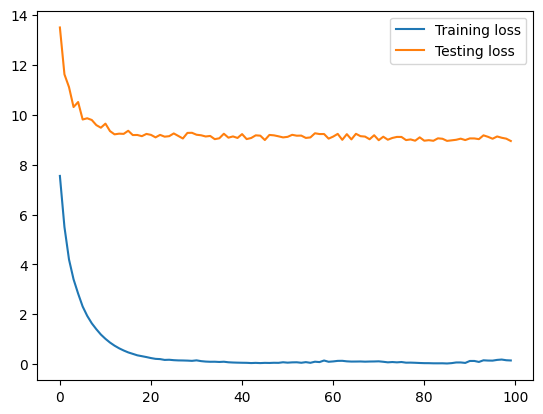

In [49]:
plt.plot(training_loss, label = 'Training loss')
plt.plot(testing_loss, label = 'Testing loss')
plt.legend(loc = 'upper right')
plt.show()

##### calculate empirical FC & model FC

In [50]:
empirical_FC = NPI.corrcoef(signals)
model_FC = NPI.model_FC(ANN, node_num = ROI_num, steps = using_steps)

##### calculate NPI Inferred EC

In [51]:
NPI_EC = NPI.model_EC(ANN, inputs, targets, pert_strength = 1.0)
np.fill_diagonal(NPI_EC, 0)

##### empirical FC - model FC comparison

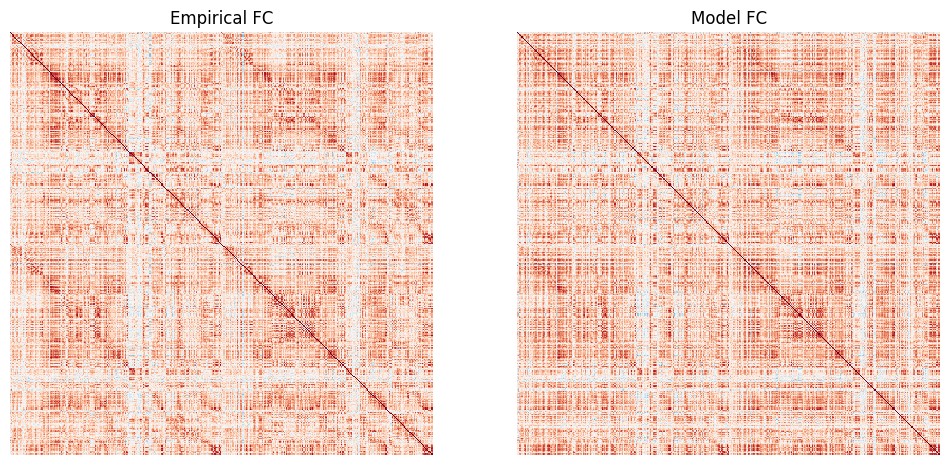

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 6))
sns.heatmap(empirical_FC, ax = ax1, vmin = -1.0, vmax = 1.0, cmap = 'RdBu_r', cbar = False, square = True, xticklabels = False, yticklabels = False)
sns.heatmap(model_FC, ax = ax2, vmin = -1.0, vmax = 1.0, cmap = 'RdBu_r', cbar = False, square = True, xticklabels = False, yticklabels = False)
ax1.set_title('Empirical FC'); ax2.set_title('Model FC')
plt.show()

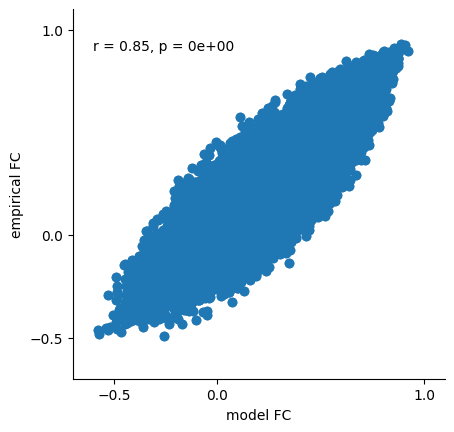

In [ ]:
r_value, p_value = pearsonr(flat_without_diagonal(model_FC), flat_without_diagonal(empirical_FC))

plt.figure(figsize = (4.8, 4.8))
plt.scatter(flat_without_diagonal(model_FC), flat_without_diagonal(empirical_FC))

plt.xlim(-0.7, 1.1); plt.xticks([-0.5, 0.0, 1.0]); plt.xlabel('model FC')
plt.ylim(-0.7, 1.1); plt.yticks([-0.5, 0.0, 1.0]); plt.ylabel('empirical FC')
plt.text(-0.6, 0.9, 'r = {:.2f}, p = {:.0e}'.format(r_value, p_value))

ax = plt.gca()
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)

plt.show()

##### NPI EC (individual)

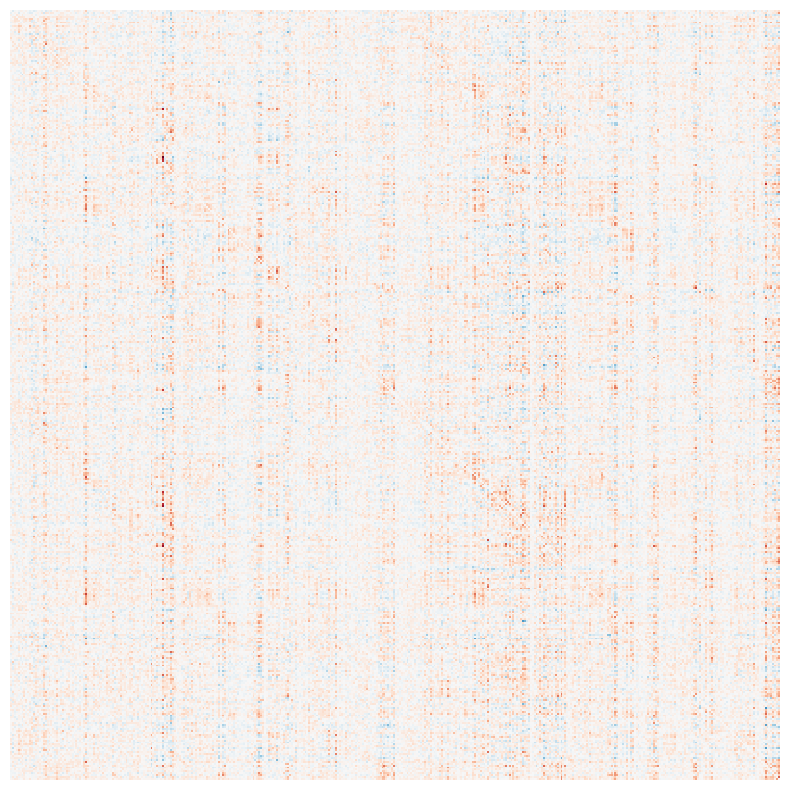

In [55]:
fig = plt.figure(figsize = (10, 10))
sns.heatmap(NPI_EC, vmin=-0.05, vmax = 0.05, cmap = 'RdBu_r', cbar = False, square = True, xticklabels = False, yticklabels = False)
plt.show()